<a href="https://colab.research.google.com/github/ananthiananthi76999-bit/Project-1/blob/main/sales_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving sales_data.csv to sales_data (1).csv
User uploaded file "sales_data (1).csv" with length 867 bytes


In [ ]:
import pandas as pd
df=pd.read_csv("sales_data.csv")
df

,Id,Product,Category,Quantity,Price,Date
0,101,Phone,Electronics,2.0,15000,2026-01-10
1,102,Shirt,Clothing,3.0,1000,2026-02-15
2,103,Laptop,Electronics,1.0,50000,2026-03-05
3,104,Rice,Grocery,5.0,500,2026-01-20
4,105,Shoes,Clothing,NaN,2000,2026-02-25
5,106,TV,Electronics,1.0,30000,NaN
6,107,Watch,Accessories,2.0,3000,2026-04-05
7,108,Bag,Accessories,3.0,1500,2026-04-15
8,109,Milk,Grocery,4.0,60,2026-05-01
9,110,Bread,Grocery,5.0,40,2026-05-03


In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Id          0
Product     0
Category    0
Quantity    1
Price       0
Date        1
dtype: int64


In [ ]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
0


In [ ]:
df.dropna(inplace=True)
df

,Id,Product,Category,Quantity,Price,Date
0,101,Phone,Electronics,2.0,15000,2026-01-10
1,102,Shirt,Clothing,3.0,1000,2026-02-15
2,103,Laptop,Electronics,1.0,50000,2026-03-05
3,104,Rice,Grocery,5.0,500,2026-01-20
6,107,Watch,Accessories,2.0,3000,2026-04-05
7,108,Bag,Accessories,3.0,1500,2026-04-15
8,109,Milk,Grocery,4.0,60,2026-05-01
9,110,Bread,Grocery,5.0,40,2026-05-03
10,111,Headphones,Electronics,2.0,2500,2026-06-10
11,112,Jacket,Clothing,1.0,3500,2026-06-15


In [ ]:
df['total']=df['Quantity']*df['Price']
df

,Id,Product,Category,Quantity,Price,Date,total
0,101,Phone,Electronics,2.0,15000,2026-01-10,30000.0
1,102,Shirt,Clothing,3.0,1000,2026-02-15,3000.0
2,103,Laptop,Electronics,1.0,50000,2026-03-05,50000.0
3,104,Rice,Grocery,5.0,500,2026-01-20,2500.0
6,107,Watch,Accessories,2.0,3000,2026-04-05,6000.0
7,108,Bag,Accessories,3.0,1500,2026-04-15,4500.0
8,109,Milk,Grocery,4.0,60,2026-05-01,240.0
9,110,Bread,Grocery,5.0,40,2026-05-03,200.0
10,111,Headphones,Electronics,2.0,2500,2026-06-10,5000.0
11,112,Jacket,Clothing,1.0,3500,2026-06-15,3500.0


In [ ]:
top_products=df.groupby('Product')['total'].sum().sort_values(ascending=False)
print("Top Selling Products:")
print(top_products)

Top Selling Products:
Product
Phone           60000.0
Laptop          50000.0
Saree            8000.0
Watch            6000.0
Headphones       5000.0
Bag              4500.0
Jacket           3500.0
Sandals          3000.0
Shirt            3000.0
Rice             2500.0
Perfume          2500.0
Mouse            1600.0
Keyboard         1200.0
Charger          1000.0
Mobile Cover      800.0
Oil               600.0
Milk              240.0
Bread             200.0
Name: total, dtype: float64


In [ ]:
print(df.columns)

Index(['Id', 'Product', 'Category', 'Quantity', 'Price', 'Date', 'total'], dtype='object')


In [ ]:
df['Date']=pd.to_datetime(df['Date'])
monthly_sales=df.groupby(df['Date'].dt.month)['total'].sum()
print("Monthly Sales Trends:")
print(monthly_sales)

Monthly Sales Trends:
Date
1    62500.0
2     3000.0
3    50000.0
4    10500.0
5      440.0
6     8500.0
7     3600.0
8     9600.0
9     5500.0
Name: total, dtype: float64


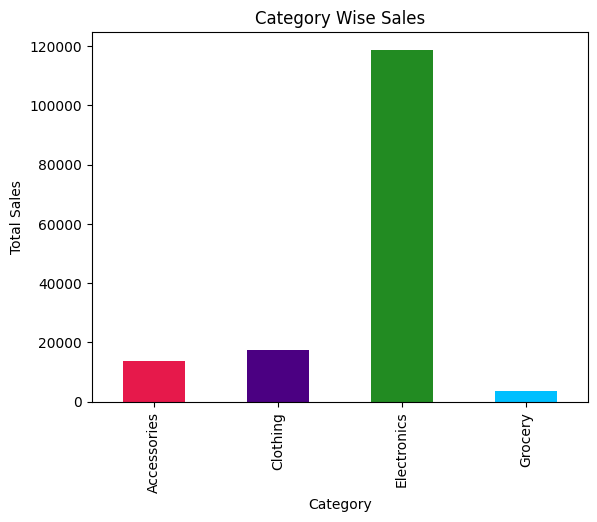

In [ ]:
import matplotlib.pyplot as plt
category_sales = df.groupby('Category')['total'].sum()
dark_custom_colors = ['#e6194b', '#4b0082', '#228b22', '#00bfff']
category_sales.plot(kind='bar', color=dark_custom_colors)
plt.title("Category Wise Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

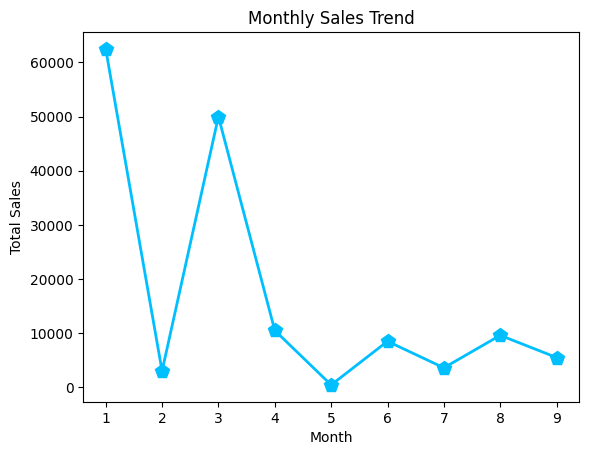

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
df['Date'] = pd.to_datetime(df['Date'])
monthly_sales = df.groupby(df['Date'].dt.month)['total'].sum()
monthly_sales.plot(kind='line', marker='p', color='#00bfff', markersize=10, linewidth=2)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()